In [4]:
import sys
print(sys.executable)
print(sys.version)
!{sys.executable} -m pip install opencv-python torch pandas


c:\Users\Admin\AppData\Local\Programs\Python\Python312\python.exe
3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip



  Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl.metadata (20 kB)
  Using cached numpy-2.4.1-cp312-cp312-win_amd64.whl.metadata (6.6 kB)
Using cached opencv_python-4.13.0.90-cp37-abi3-win_amd64.whl (40.2 MB)
Using cached numpy-2.4.1-cp312-cp312-win_amd64.whl (12.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.3
    Uninstalling numpy-1.26.3:
      Successfully uninstalled numpy-1.26.3


In [1]:
import os
import cv2
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [2]:
# Dataset PyTorch pour eyetracking

class EyeTrackingDataset(Dataset):
    def __init__(self, csv_file, img_dir, img_size=(224,224), transform=None):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.img_size = img_size
        self.transform = transform

        # filtrer les lignes où l'image existe et est valide
        valid_indices = []
        for idx, row in self.df.iterrows():
            fid = int(row['frame_id'])
            img_path = os.path.join(img_dir, f"frame_{fid:04d}.png")
            if os.path.exists(img_path):
                img = cv2.imread(img_path)
                if img is not None and len(img.shape) == 3 and img.shape[0] > 0 and img.shape[1] > 0:
                    valid_indices.append(idx)
        self.df = self.df.iloc[valid_indices].reset_index(drop=True)

        # créer mapping frame_id -> image path
        self.img_paths = [os.path.join(img_dir, f"frame_{int(fid):04d}.png") 
                          for fid in self.df['frame_id']]

        # extraire les coordonnées
        self.coords = self.df[['x','y']].values.astype(np.float32)

        # Calculer les maxima pour normalisation
        self.max_x = 1272 #np.max(self.coords[:, 0])
        self.max_y = 712 #np.max(self.coords[:, 1])

        # Normaliser toutes les coordonnées
        self.coords[:, 0] /= self.max_x
        self.coords[:, 1] /= self.max_y
        

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = cv2.imread(img_path)
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # resize
        img = cv2.resize(img, self.img_size)

        # coordonnées déjà normalisées
        x, y = self.coords[idx]
        label = torch.tensor([x, abs(y)], dtype=torch.float32)

        # transform PyTorch (ToTensor + normalisation)
        if self.transform:
            img = self.transform(img)
        else:
            # default transform
            img = transforms.ToTensor()(img)
            img = transforms.Normalize([0.5,0.5,0.5],[0.5,0.5,0.5])(img)

        return img, label

In [3]:
csv_file = "C:\\Users\\Admin\\Documents\\5A\\a_learning\\AL_project\\active_learning\\data\\coords_20260121_082431.csv"

# Créer les datasets séparés
train_dataset = EyeTrackingDataset(csv_file, "data/dataset/train")
dev_dataset = EyeTrackingDataset(csv_file, "data/dataset/dev")
test_dataset = EyeTrackingDataset(csv_file, "data/dataset/test")

print(f"Train size: {len(train_dataset)}")
print(f"Dev size: {len(dev_dataset)}")
print(f"Test size: {len(test_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Vérification rapide
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels.shape)  # imgs: [B,3,H,W], labels: [B,2]

Train size: 1248
Dev size: 269
Test size: 268
torch.Size([32, 3, 224, 224]) torch.Size([32, 2])


In [4]:
print(train_dataset.max_x, train_dataset.max_y)
print(dev_dataset.max_x, dev_dataset.max_y)
print(test_dataset.max_x, test_dataset.max_y)

1272 712
1272 712
1272 712


In [5]:
# Définition du modèle CNN pour prédiction du regard
import torch.nn as nn

class GazeNet(nn.Module):
    def __init__(self):
        super(GazeNet, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(4, 4)
        self.fc1 = nn.Linear(6272, 256)
        self.fc2 = nn.Linear(256, 2)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.shape[0], -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

model = GazeNet()
print("number of parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))


number of parameters: 1611490


In [7]:

import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20  

In [8]:
# Comparaison avec un modèle aléatoire (non entraîné)

random_model = GazeNet()  

random_model.eval()
random_test_loss = 0.0
random_preds = []
random_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = random_model(imgs)
        loss = criterion(outputs, labels)
        random_test_loss += loss.item()
        random_preds.append(outputs.cpu())
        random_labels.append(labels.cpu())

random_preds = torch.cat(random_preds)
random_labels = torch.cat(random_labels)

random_mae = torch.mean(torch.abs(random_preds - random_labels)).item()
random_rmse = torch.sqrt(torch.mean((random_preds - random_labels)**2)).item()

# Accuracy pour random
random_distances = torch.sqrt(torch.sum((random_preds - random_labels)**2, dim=1))
random_accuracy = (random_distances < 0.1).float().mean().item() * 100

print(f"Test Loss du modèle aléatoire (MSE): {random_test_loss/len(test_loader):.4f}")
print(f"Test MAE du modèle aléatoire: {random_mae:.4f}")
print(f"Test RMSE du modèle aléatoire: {random_rmse:.4f}")


Test Loss du modèle aléatoire (MSE): 0.0437
Test MAE du modèle aléatoire: 0.1590
Test RMSE du modèle aléatoire: 0.2122


In [9]:
# Pour stocker les pertes et accuracies
train_losses = []
val_losses = []
train_maes = []
val_maes = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    running_mae = 0.0
    count = 0
    for imgs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        mae = torch.mean(torch.abs(outputs - labels)).item()
        running_mae += mae
        count += 1
    
    train_loss = running_loss / count
    train_mae = running_mae / count
    train_losses.append(train_loss)
    train_maes.append(train_mae)
    
    # Validation
    model.eval()
    val_loss = 0.0
    val_mae = 0.0
    count = 0
    with torch.no_grad():
        for imgs, labels in dev_loader:
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            mae = torch.mean(torch.abs(outputs - labels)).item()
            val_mae += mae
            count += 1
    
    val_loss = val_loss / count
    val_mae = val_mae / count
    val_losses.append(val_loss)
    val_maes.append(val_mae)
    
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Train MAE: {train_mae:.4f}, Val Loss: {val_loss:.4f}, Val MAE: {val_mae:.4f}")

print("Entraînement terminé.")

Epoch 1/20, Train Loss: 0.0542, Train MAE: 0.1891, Val Loss: 0.0347, Val MAE: 0.1366
Epoch 2/20, Train Loss: 0.0387, Train MAE: 0.1484, Val Loss: 0.0238, Val MAE: 0.1276
Epoch 3/20, Train Loss: 0.0265, Train MAE: 0.1114, Val Loss: 0.0161, Val MAE: 0.1041
Epoch 4/20, Train Loss: 0.0196, Train MAE: 0.0930, Val Loss: 0.0195, Val MAE: 0.0989
Epoch 5/20, Train Loss: 0.0168, Train MAE: 0.0849, Val Loss: 0.0122, Val MAE: 0.0768
Epoch 6/20, Train Loss: 0.0146, Train MAE: 0.0785, Val Loss: 0.0122, Val MAE: 0.0791
Epoch 7/20, Train Loss: 0.0129, Train MAE: 0.0746, Val Loss: 0.0178, Val MAE: 0.0937
Epoch 8/20, Train Loss: 0.0120, Train MAE: 0.0718, Val Loss: 0.0140, Val MAE: 0.0806
Epoch 9/20, Train Loss: 0.0099, Train MAE: 0.0651, Val Loss: 0.0227, Val MAE: 0.1010
Epoch 10/20, Train Loss: 0.0093, Train MAE: 0.0629, Val Loss: 0.0182, Val MAE: 0.0918
Epoch 11/20, Train Loss: 0.0078, Train MAE: 0.0581, Val Loss: 0.0194, Val MAE: 0.0925
Epoch 12/20, Train Loss: 0.0076, Train MAE: 0.0568, Val Loss: 0

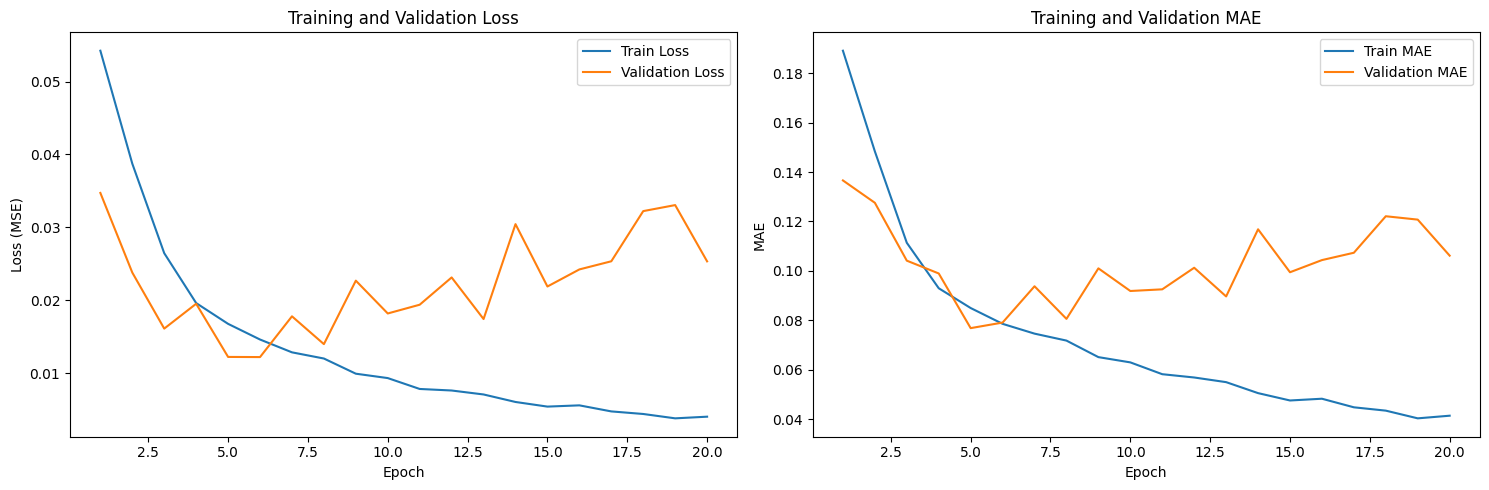

In [10]:
# Affichage des courbes de perte et MAE
import matplotlib.pyplot as plt

epochs = range(1, num_epochs + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Courbes de Loss
ax1.plot(epochs, train_losses, label='Train Loss')
ax1.plot(epochs, val_losses, label='Validation Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# Courbes de MAE
ax2.plot(epochs, train_maes, label='Train MAE')
ax2.plot(epochs, val_maes, label='Validation MAE')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('MAE')
ax2.set_title('Training and Validation MAE')
ax2.legend()

plt.tight_layout()
plt.show()

In [11]:
# Évaluation sur le test set

model.eval()
test_loss = 0.0
all_preds = []
all_labels = []
with torch.no_grad():
    for imgs, labels in test_loader:
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        all_preds.append(outputs.cpu())
        all_labels.append(labels.cpu())

all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)

# Calcul des métriques
mae = torch.mean(torch.abs(all_preds - all_labels)).item()
rmse = torch.sqrt(torch.mean((all_preds - all_labels)**2)).item()

# Accuracy: pourcentage de prédictions avec distance euclidienne < 0.1
distances = torch.sqrt(torch.sum((all_preds - all_labels)**2, dim=1))
accuracy = (distances < 0.1).float().mean().item() * 100

print(f"Test Loss (MSE): {test_loss/len(test_loader):.4f}")
print(f"Test MAE: {mae:.4f}")
print(f"Test RMSE: {rmse:.4f}")
print(f"Test Accuracy (dist < 0.1): {accuracy:.2f}%")

# Sauvegarder le modèle
torch.save(model.state_dict(), 'gaze_model.pth')
print("Modèle sauvegardé.")

Test Loss (MSE): 0.0443
Test MAE: 0.1483
Test RMSE: 0.2097
Test Accuracy (dist < 0.1): 20.52%
Modèle sauvegardé.


Center predictor — MSE: 0.0444, MAE: 0.1539, RMSE: 0.2106, Acc(dist<0.1): 13.06%
Mean predictor  — MSE: 0.0426, MAE: 0.1442, RMSE: 0.2064, Acc(dist<0.1): 18.28%
Uniform random  — MSE: 0.1224, MAE: 0.2879, RMSE: 0.3499, Acc(dist<0.1): 2.61%
Random model outputs mean: [0.48565093 0.49038213] std: [0.00054951 0.00061093]
Labels stats (norm) x -> mean: 0.5531, std: 0.0454, min: 0.4748, max: 0.6313
Labels stats (norm) y -> mean: 0.4733, std: 0.2884, min: 0.0098, max: 1.0000


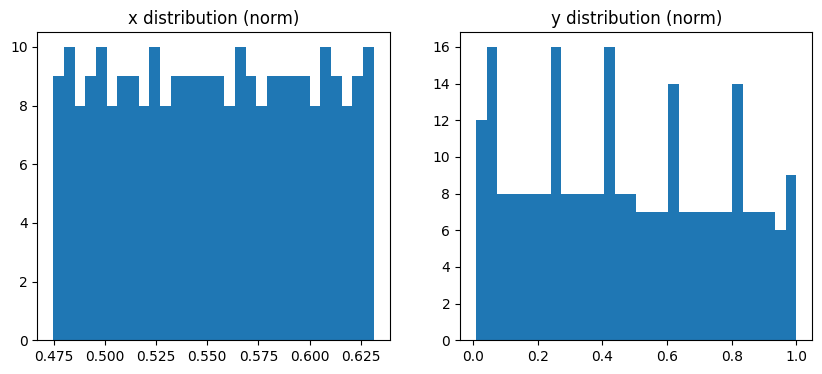

Nombre de y négatifs dans test df: 4 / 268
MAE en pixels (center): 152.68px
MAE en pixels (mean): 143.03px
MAE en pixels (uniform random): 285.58px
MAE en pixels (modèle entraîné): 147.08px


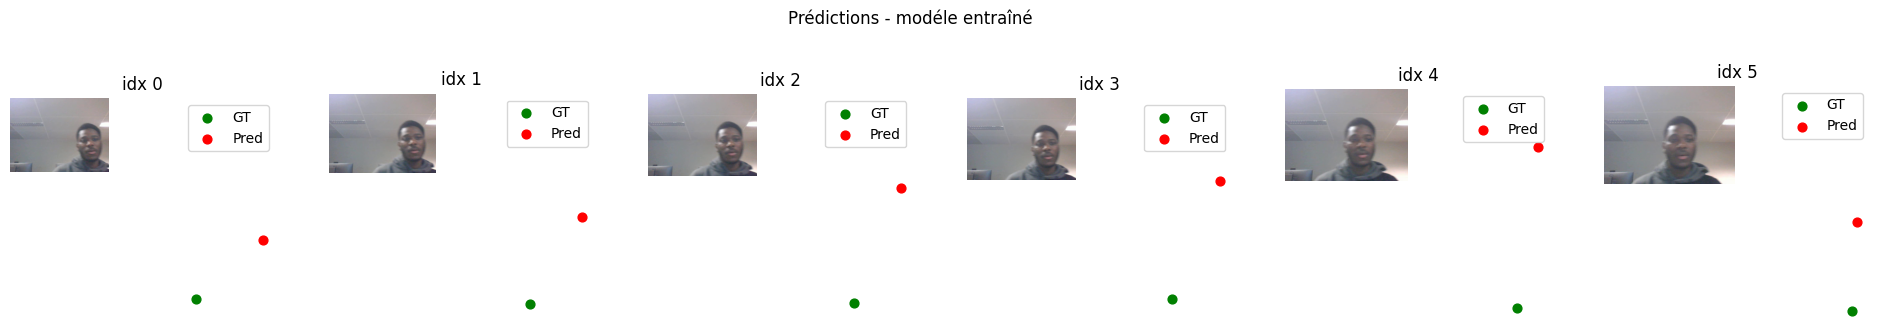

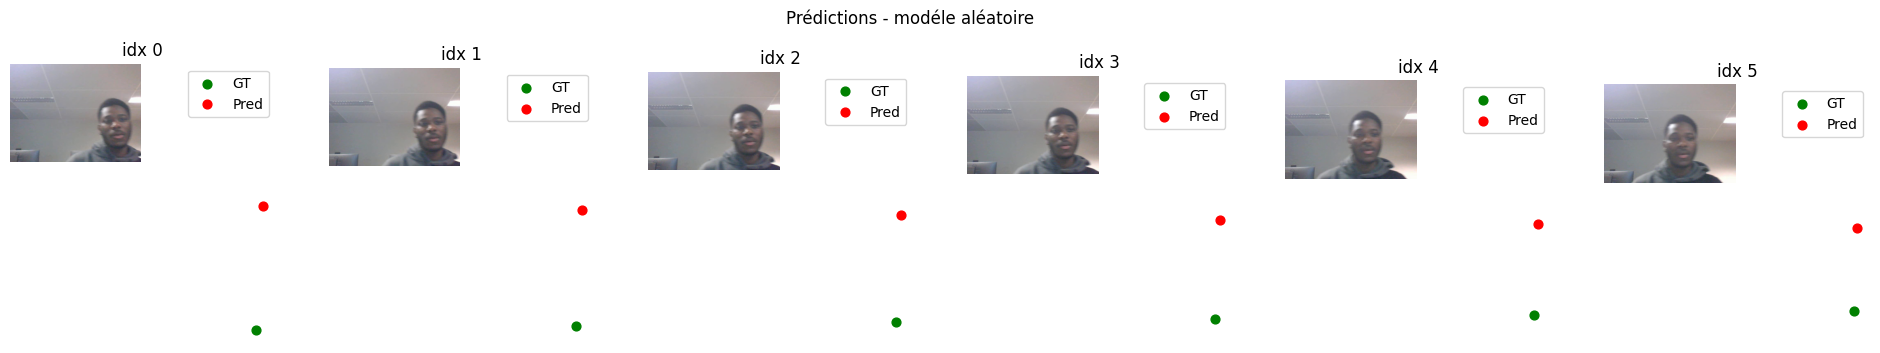

Fraction de y modifiés par abs(): 1.49%

Diagnostics terminés. Recommande: retirer abs(y) si inutile, et comparer les baselines (center/mean) aux performances actuelles.


In [13]:
# Diagnostics supplémentaires — baselines, distribution, vérifications et visualisations
# - Calcule des baselines (center / mean / uniform random)
# - Inspecte la distribution des labels (normalisés)
# - Vérifie la moyenne/écart-type des sorties du modèle aléatoire
# - Affiche des overlays (GT vs prédictions) pour le modèle entraîné et le modèle aléatoire

import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2

# helper pour évaluer un prédicteur sur un DataLoader
def eval_predictor(predict_fn, loader):
    preds = []
    labels = []
    with torch.no_grad():
        for imgs, labs in loader:
            p = predict_fn(imgs)
            preds.append(p.cpu())
            labels.append(labs.cpu())
    preds = torch.cat(preds)
    labels = torch.cat(labels)
    mse = torch.mean((preds - labels)**2).item()
    mae = torch.mean(torch.abs(preds - labels)).item()
    rmse = torch.sqrt(torch.mean((preds - labels)**2)).item()
    dists = torch.sqrt(torch.sum((preds - labels)**2, dim=1))
    acc = (dists < 0.1).float().mean().item() * 100
    return {'preds':preds, 'labels':labels, 'mse':mse,'mae':mae,'rmse':rmse,'acc':acc, 'dists':dists}

# Center predictor (prévoit [0.5,0.5])
def center_predictor(imgs):
    b = imgs.shape[0]
    return torch.full((b,2), 0.5)

center_res = eval_predictor(lambda imgs: center_predictor(imgs), test_loader)
print("Center predictor — MSE: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}, Acc(dist<0.1): {:.2f}%".format(center_res['mse'], center_res['mae'], center_res['rmse'], center_res['acc']))

# Mean predictor (moyenne des labels du test)
all_test_labels = torch.cat([labs for _, labs in test_loader])
mean_label = torch.mean(all_test_labels, dim=0)
def mean_predictor(imgs):
    b = imgs.shape[0]
    return mean_label.unsqueeze(0).repeat(b,1)

mean_res = eval_predictor(lambda imgs: mean_predictor(imgs), test_loader)
print("Mean predictor  — MSE: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}, Acc(dist<0.1): {:.2f}%".format(mean_res['mse'], mean_res['mae'], mean_res['rmse'], mean_res['acc']))

# Uniform random predictor
def uniform_random_predictor(imgs):
    return torch.rand(imgs.shape[0],2)

rand_res = eval_predictor(lambda imgs: uniform_random_predictor(imgs), test_loader)
print("Uniform random  — MSE: {:.4f}, MAE: {:.4f}, RMSE: {:.4f}, Acc(dist<0.1): {:.2f}%".format(rand_res['mse'], rand_res['mae'], rand_res['rmse'], rand_res['acc']))

# Stats du modèle aléatoire (sorties)
if 'random_preds' in globals():
    rand_outs = random_preds
else:
    temp_preds = []
    with torch.no_grad():
        for imgs, labs in test_loader:
            temp_preds.append(GazeNet()(imgs).cpu())
    rand_outs = torch.cat(temp_preds)
print("Random model outputs mean:", rand_outs.mean(dim=0).numpy(), "std:", rand_outs.std(dim=0).numpy())

# Distribution des labels (normalisés)
labels = torch.cat([labs for _, labs in test_loader])
x = labels[:,0].numpy()
y = labels[:,1].numpy()
print("Labels stats (norm) x -> mean: {:.4f}, std: {:.4f}, min: {:.4f}, max: {:.4f}".format(x.mean(), x.std(), x.min(), x.max()))
print("Labels stats (norm) y -> mean: {:.4f}, std: {:.4f}, min: {:.4f}, max: {:.4f}".format(y.mean(), y.std(), y.min(), y.max()))
plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.hist(x, bins=30); plt.title('x distribution (norm)')
plt.subplot(1,2,2); plt.hist(y, bins=30); plt.title('y distribution (norm)')
plt.show()

# Proportion de y négatifs dans le CSV (avant abs)
if hasattr(test_dataset, 'df'):
    neg_y = (test_dataset.df['y'] < 0).sum()
    print(f"Nombre de y négatifs dans test df: {neg_y} / {len(test_dataset.df)}")

# Conversion MAE normalisée -> pixels (approx moyenne des axes)
def mae_norm_to_pixels(mae_norm, max_x=test_dataset.max_x, max_y=test_dataset.max_y):
    return mae_norm * ((max_x + max_y) / 2.0)

print("MAE en pixels (center): {:.2f}px".format(mae_norm_to_pixels(center_res['mae'])))
print("MAE en pixels (mean): {:.2f}px".format(mae_norm_to_pixels(mean_res['mae'])))
print("MAE en pixels (uniform random): {:.2f}px".format(mae_norm_to_pixels(rand_res['mae'])))
if 'mae' in globals():
    print("MAE en pixels (modèle entraîné): {:.2f}px".format(mae_norm_to_pixels(mae)))

# Fonction d'affichage overlay GT vs Pred
def show_overlays(dataset, preds_norm, n=6, title=''):
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    for i in range(n):
        img_path = dataset.img_paths[i]
        img = cv2.imread(img_path)
        if img is None:
            axes[i].text(0.5,0.5,'Image non trouvée',ha='center')
            axes[i].axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        gt = dataset.coords[i]  # normalisé
        pred = preds_norm[i].numpy()
        gt_px = (gt[0]*dataset.max_x, gt[1]*dataset.max_y)
        pred_px = (pred[0]*dataset.max_x, pred[1]*dataset.max_y)
        axes[i].imshow(img); axes[i].scatter([gt_px[0]],[gt_px[1]], c='g', s=40, label='GT')
        axes[i].scatter([pred_px[0]],[pred_px[1]], c='r', s=40, label='Pred')
        axes[i].axis('off'); axes[i].set_title(f'idx {i}')
        axes[i].legend()
    plt.suptitle(title)
    plt.show()

# Prédictions du modèle entraîné sur le test set
trained_preds = []
with torch.no_grad():
    for imgs, labs in test_loader:
        trained_preds.append(model(imgs).cpu())
trained_preds = torch.cat(trained_preds)
show_overlays(test_dataset, trained_preds, n=6, title='Prédictions - modéle entraîné')

# Prédictions du modèle aléatoire sur le test set
rand_model_preds = []
with torch.no_grad():
    for imgs, labs in test_loader:
        rand_model_preds.append(random_model(imgs).cpu())
rand_model_preds = torch.cat(rand_model_preds)
show_overlays(test_dataset, rand_model_preds, n=6, title='Prédictions - modéle aléatoire')

# Effet de abs(y)
orig_y = test_dataset.df['y'].values.astype(np.float32)
frac_abs_changed = float(np.mean(np.abs(orig_y) != orig_y))
print("Fraction de y modifiés par abs(): {:.2%}".format(frac_abs_changed))

print('\nDiagnostics terminés. Recommande: retirer abs(y) si inutile, et comparer les baselines (center/mean) aux performances actuelles.')

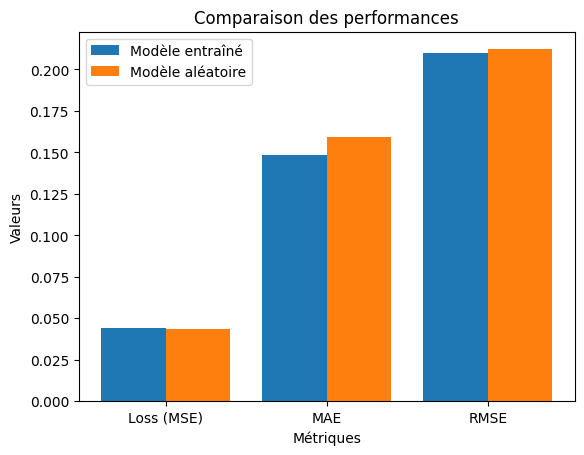

In [12]:
# Comparaison des métriques finales
import matplotlib.pyplot as plt

metrics = ['Loss (MSE)', 'MAE', 'RMSE']
trained_values = [test_loss / len(test_loader), mae, rmse]
random_values = [random_test_loss / len(test_loader), random_mae, random_rmse]

x = range(len(metrics))
plt.bar(x, trained_values, width=0.4, label='Modèle entraîné', align='center')
plt.bar([i + 0.4 for i in x], random_values, width=0.4, label='Modèle aléatoire', align='center')
plt.xlabel('Métriques')
plt.ylabel('Valeurs')
plt.title('Comparaison des performances')
plt.xticks([i + 0.2 for i in x], metrics)
plt.legend()
plt.show()